# 04 · OE5 — Modelo predictivo (XGBoost) y anticipación de franjas de presión
**Iván Ramiro Pinzón Pinto** — Ciencia de Datos, Universidad Externado de Colombia · Tutora: Yessica Velásquez

*Implementa §3.8 (modelo, búsqueda de hiperparámetros, validación cruzada temporal y anticipación de franjas de presión).* **Requiere `03_OE4_conglomerados`.**

In [1]:
import pandas as pd
import numpy as np
import json
import re
import os
import warnings
from glob import glob
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from itertools import combinations
from matplotlib.patches import Patch
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.inspection import permutation_importance
from sklearn.metrics import adjusted_rand_score, silhouette_samples
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Librerías cargadas correctamente.")

c:\Users\ivanr\.conda\envs\pyfhel\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


### Carga de insumos


In [2]:
import os
from pathlib import Path
import pandas as pd

# Raíz del proyecto: sube hasta encontrar un marcador del repo (sirve corra donde corra el kernel)
def raiz_proyecto(marcadores=('.git', 'requirements.txt', 'README.md')):
    d = Path.cwd().resolve()
    for cand in (d, *d.parents):
        if any((cand / m).exists() for m in marcadores):
            return cand
    return d

RAIZ = raiz_proyecto()
DATA_INT = os.path.join(RAIZ, 'data', 'intermedia')
OUT_FIG  = os.path.join(RAIZ, 'outputs', 'figuras')
OUT_TAB  = os.path.join(RAIZ, 'outputs', 'tablas')
os.makedirs(OUT_FIG, exist_ok=True); os.makedirs(OUT_TAB, exist_ok=True)

ipd_df     = pd.read_parquet(os.path.join(DATA_INT, 'panel_con_clusters.parquet'))
cluster_df = pd.read_parquet(os.path.join(DATA_INT, 'cluster_df.parquet'))
icp        = pd.read_parquet(os.path.join(DATA_INT, 'icp.parquet'))
print(f'Panel con conglomerado: {len(ipd_df):,} filas')


Panel con conglomerado: 8,192,438 filas


## 1. Modelo predictivo de demanda y anticipación de franjas de presión — §3.8

Modelo supervisado (XGBoost) para predecir la demanda por estación y franja horaria. Para aislar el aporte estructural de los indicadores se comparan **cuatro especificaciones** que comparten las mismas variables temporales:

- **M0 (temporal):** solo franja horaria, día de la semana, mes, año, fin de semana y festivo.
- **M1 (efectos fijos de estación):** M0 + `estacion_code` (identificador por estación; captura cualquier particularidad de la estación sin teoría).
- **M2 (estructural):** M0 + ICP, número de rutas y conglomerado de presión (**sin** `estacion_code`).
- **M3 (anticipación):** M2 + el rezago de las validaciones de la misma estación y franja **7 días atrás**, conocido al momento de predecir en un escenario operativo (§3.8).

**M2 vs M0** mide el aporte de la información estructural por encima del tiempo; **M2 vs M1**, más exigente, evalúa si unas pocas variables estructurales interpretables recuperan lo que harían los efectos fijos por estación; **M3 vs M2** cuantifica el aporte de la historia reciente (evaluado solo sobre observaciones con rezago disponible). Las cuatro comparten el **mismo espacio de búsqueda y la misma configuración de hiperparámetros**, de modo que las diferencias se deben a las variables y no al ajuste del algoritmo.

**Decisiones de §3.8 implementadas en este cuaderno:**
- **Objetivo Poisson** (`count:poisson`): la variable objetivo es un conteo no negativo, asimétrico y con exceso de ceros nocturnos; con error cuadrático, las estaciones de alta demanda dominarían el ajuste. Se contrasta con error cuadrático sobre log(1+y) como verificación de robustez.
- **Partición temporal 80/20** (no aleatoria): evita la filtración de información futura al entrenamiento.
- **XGBoost** por su manejo de no linealidades, su regularización explícita y sus importancias interpretables (gain + SHAP). Random Forest y LightGBM se entrenan como puntos de referencia para verificar que la elección del algoritmo no condiciona las conclusiones; se descartan arquitecturas profundas por interpretabilidad y porque en datos tabulares los métodos de árboles son consistentemente competitivos (Grinsztajn et al., 2022).
- A partir del **IPD esperado** (demanda predicha / ICP) se anticipan las franjas de presión alta: presión relativa a la cobertura asignada, no saturación física.

In [3]:
# =============================================
# PREPARACIÓN DE FEATURES Y TRES MODELOS ANIDADOS
# =============================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Conglomerado SIN FUGA: el perfil de IPD y el K-Means se reajustan usando SOLO el
# periodo de entrenamiento (80% temporal), de modo que la etiqueta de cluster usada
# como predictor no incorpora informacion del conjunto de prueba. El cluster del OE4
# (periodo completo, todos los meses) se conserva para la caracterizacion descriptiva.
split_date = ipd_df['fecha'].quantile(0.8)
ipd_train  = ipd_df[ipd_df['fecha'] <= split_date]

perf_tr = ipd_train.groupby(['estacion', 'hora'])['ipd'].mean().unstack(fill_value=0)
perf_tr['ipd_mean'] = perf_tr.mean(axis=1)
perf_tr['ipd_std']  = perf_tr.iloc[:, :-1].std(axis=1)
perf_tr['ipd_max']  = perf_tr.iloc[:, :-2].max(axis=1)
perf_tr.columns = perf_tr.columns.astype(str)

scaler_cl = StandardScaler()
km_tr = KMeans(n_clusters=4, random_state=42, n_init=10)
perf_tr['cluster_tr'] = km_tr.fit_predict(scaler_cl.fit_transform(perf_tr))

# Alinear la numeracion con los conglomerados del OE4 (por mayoria de estaciones
# compartidas), para conservar la tipologia C0-C3 del capitulo de hallazgos.
ref = cluster_df.set_index('estacion')['cluster']
align = (perf_tr[['cluster_tr']].join(ref.rename('oe4')).dropna()
         .groupby('cluster_tr')['oe4'].agg(lambda s: int(s.mode().iloc[0])).to_dict())
perf_tr['cluster'] = perf_tr['cluster_tr'].map(align)
cluster_map = perf_tr['cluster'].to_dict()
ipd_df['cluster'] = ipd_df['estacion'].map(cluster_map)

# Concordancia con el cluster del OE4 (periodo completo): si es alta, la fuga era marginal
comp = perf_tr.join(ref.rename('oe4')).dropna(subset=['oe4'])
ari_tr = adjusted_rand_score(comp['oe4'].astype(int), comp['cluster'].astype(int))
del ipd_train, perf_tr, comp

# Codigo de estacion: identificador categorico (solo para el modelo de efectos fijos M1)
station_codes = {s: i for i, s in enumerate(sorted(ipd_df['estacion'].unique()))}
ipd_df['estacion_code'] = ipd_df['estacion'].map(station_codes)

# Resolución temporal de 15 min: 'hora' (0-23) no distingue las 8:00 de las 8:45;
# el objetivo está a 15 min. Se usa el índice de franja del día ('intervalo' ya viene
# en el panel). La columna 'hora' se conserva para los gráficos por hora.
ipd_df['minuto']     = pd.to_numeric(ipd_df['intervalo'].astype(str).str.split(':').str[1], errors='coerce')
ipd_df['franja_idx'] = ipd_df['hora'] * 4 + ipd_df['minuto'] // 15

# Año: permite modelar el nivel por año en entrenamiento (cambios 2024->2025).
ipd_df['anio'] = ipd_df['fecha'].dt.year

# Rezago autorregresivo: demanda de la MISMA estación, MISMA franja, 7 días antes
# (mismo día de la semana). Mira solo hacia atrás en el tiempo -> sin fuga al test.
_lag_src = (ipd_df[['estacion', 'fecha', 'intervalo', 'validaciones']]
            .rename(columns={'fecha': 'fecha_lag', 'validaciones': 'lag_7d'}))
ipd_df['fecha_lag'] = ipd_df['fecha'] - pd.Timedelta(days=7)
ipd_df = ipd_df.merge(_lag_src, on=['estacion', 'fecha_lag', 'intervalo'], how='left')

# --- ESPECIFICACIONES DEL MODELO ---
feat_temporal   = ['franja_idx', 'dia_semana', 'mes', 'anio', 'es_fin_semana', 'es_festivo']
feat_estacion   = feat_temporal + ['estacion_code']             # M1: efectos fijos de estación (código entero)
feat_estructura = feat_temporal + ['icp', 'n_rutas', 'cluster']  # M2: estructura (SIN estacion_code)
feat_autorreg   = feat_estructura + ['lag_7d']                   # M3: M2 + rezago autorregresivo (7 días)
MODELOS = {'M0_temporal': feat_temporal,
           'M1_efectos_fijos': feat_estacion,
           'M2_estructural': feat_estructura}

# Alias de compatibilidad con el resto del cuaderno: el "base" es M0 y el "completo" es M2
base_features = feat_temporal
feature_cols  = feat_estructura

# Columnas necesarias en cualquiera de los modelos
todas_cols = feat_temporal + ['icp', 'n_rutas', 'cluster', 'estacion_code']
model_df = ipd_df.dropna(subset=todas_cols + ['validaciones']).copy()
model_df['cluster'] = model_df['cluster'].astype(int)

print(f"Conglomerado reajustado solo con train (sin fuga al test).")
print(f"ARI vs cluster del OE4 (periodo completo) = {ari_tr:.3f}  (cercano a 1 => fuga marginal)")
print(f"Datos para modelo: {len(model_df):,} filas")
for nombre, cols in MODELOS.items():
    print(f"  {nombre:18s}: {cols}")

# X contiene las variables de M2 (estructural); M1 toma estacion_code aparte (celda de modelos)
X = model_df[feature_cols]
y = model_df['validaciones']

Conglomerado reajustado solo con train (sin fuga al test).
ARI vs cluster del OE4 (periodo completo) = 0.971  (cercano a 1 => fuga marginal)
Datos para modelo: 8,192,438 filas
  M0_temporal       : ['franja_idx', 'dia_semana', 'mes', 'anio', 'es_fin_semana', 'es_festivo']
  M1_efectos_fijos  : ['franja_idx', 'dia_semana', 'mes', 'anio', 'es_fin_semana', 'es_festivo', 'estacion_code']
  M2_estructural    : ['franja_idx', 'dia_semana', 'mes', 'anio', 'es_fin_semana', 'es_festivo', 'icp', 'n_rutas', 'cluster']


In [4]:
# =============================================
# PARTICIÓN TEMPORAL (80/20)
# =============================================

# split_date ya definido en la preparacion de features (mismo corte para clusters y modelo)
train_mask = model_df['fecha'] <= split_date

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train):,} filas (hasta {split_date.strftime('%Y-%m-%d')})")
print(f"Test:  {len(X_test):,} filas (después)")

Train: 6,558,996 filas (hasta 2025-08-02)
Test:  1,633,442 filas (después)


In [5]:
# =============================================
# BÚSQUEDA DE HIPERPARÁMETROS (TimeSeriesSplit sobre el train)
# =============================================
# La configuracion se busca sobre el modelo estructural (M2) con validacion cruzada
# temporal de ventana expansible y se aplica IDENTICA a los tres modelos, de modo que
# las diferencias se deban a las variables y no al ajuste. Objetivo Poisson (conteo).
# El espacio coincide con el descrito en §3.8.
# NOTA: es la celda mas costosa del cuaderno (n_iter x n_splits ajustes). Si se necesita
# mas rapidez, reducir n_iter o muestrear temporalmente el train solo para la busqueda.
# Decisiones operativas (no fijadas por §3.8, se documentan aqui): n_iter=20 puntos de
# busqueda aleatoria (a igual presupuesto, mas eficiente que recorrer una grilla
# exhaustiva; Bergstra y Bengio, 2012) y n_splits=4 pliegues expansibles (cada
# validacion cubre ~20% del train; equilibrio entre costo y estabilidad de la
# seleccion). Ambas acotan el costo computacional sin alterar el espacio de busqueda,
# que si es exactamente el definido en §3.8.
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform

orden_tr = model_df[train_mask].sort_values('fecha').index   # orden temporal para TimeSeriesSplit
Xtr_s, ytr_s = X.loc[orden_tr], y.loc[orden_tr]

espacio = {
    'n_estimators':     randint(100, 501),     # 100 - 500
    'max_depth':        randint(4, 11),         # 4 - 10
    'learning_rate':    uniform(0.01, 0.19),    # 0.01 - 0.20
    'subsample':        uniform(0.6, 0.4),      # 0.6 - 1.0
    'colsample_bytree': uniform(0.6, 0.4),      # 0.6 - 1.0
}
base_est = XGBRegressor(objective='count:poisson', tree_method='hist',
                        random_state=42, n_jobs=-1)
buscador = RandomizedSearchCV(
    base_est, espacio, n_iter=20, cv=TimeSeriesSplit(n_splits=4),
    scoring='neg_mean_squared_error', random_state=42, n_jobs=1, verbose=1)
buscador.fit(Xtr_s, ytr_s)   # Xtr_s ya contiene las variables de M2

# Misma configuracion para los tres modelos; objetivo Poisson
xgb_params = {**buscador.best_params_, 'objective': 'count:poisson',
              'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1}
print("Mejor configuración (aplicada a los tres modelos):")
for k, v in buscador.best_params_.items():
    print(f"  {k}: {v}")

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Mejor configuración (aplicada a los tres modelos):
  colsample_bytree: 0.9140703845572055
  learning_rate: 0.047938018610088354
  max_depth: 10
  n_estimators: 343
  subsample: 0.836965827544817


In [6]:
# =============================================
# ENTRENAMIENTO DE LOS TRES MODELOS ANIDADOS
# (misma configuracion xgb_params -> objetivo Poisson)
# =============================================

# M1 necesita estacion_code, que no esta en X (features de M2); se toma de model_df
Xtr_m1 = model_df.loc[train_mask, feat_estacion]
Xte_m1 = model_df.loc[~train_mask, feat_estacion]

# M0 — temporal
xgb_base = XGBRegressor(**xgb_params); xgb_base.fit(X_train[base_features], y_train)
y_pred_base = np.clip(xgb_base.predict(X_test[base_features]), 0, None)
# M1 — efectos fijos de estacion
xgb_m1 = XGBRegressor(**xgb_params); xgb_m1.fit(Xtr_m1, y_train)
y_pred_m1 = np.clip(xgb_m1.predict(Xte_m1), 0, None)
# M2 — estructural (modelo final)
xgb_full = XGBRegressor(**xgb_params); xgb_full.fit(X_train, y_train)
y_pred_full = np.clip(xgb_full.predict(X_test), 0, None)

def met(y_true, y_pred):
    return (np.sqrt(mean_squared_error(y_true, y_pred)),
            mean_absolute_error(y_true, y_pred),
            r2_score(y_true, y_pred))

rmse_base, mae_base, r2_base = met(y_test, y_pred_base)
rmse_m1,   mae_m1,   r2_m1   = met(y_test, y_pred_m1)
rmse_full, mae_full, r2_full = met(y_test, y_pred_full)

print(f"{'Modelo':<28}{'RMSE':>10}{'MAE':>10}{'R2':>10}")
print('-' * 58)
print(f"{'M0 (temporal)':<28}{rmse_base:>10.2f}{mae_base:>10.2f}{r2_base:>10.4f}")
print(f"{'M1 (efectos fijos)':<28}{rmse_m1:>10.2f}{mae_m1:>10.2f}{r2_m1:>10.4f}")
print(f"{'M2 (estructural)':<28}{rmse_full:>10.2f}{mae_full:>10.2f}{r2_full:>10.4f}")

Modelo                            RMSE       MAE        R2
----------------------------------------------------------
M0 (temporal)                   241.14    115.09    0.1363
M1 (efectos fijos)               70.23     34.71    0.9267
M2 (estructural)                 65.86     28.74    0.9356


In [7]:
# =============================================
# M3 — MODELO ESTRUCTURAL + REZAGO AUTORREGRESIVO (7 días)
# =============================================
# Especificación de anticipación definida en §3.8: añade la demanda de la misma franja
# 7 días antes (conocida al predecir con horizonte de una semana). El rezago solo
# existe desde la 2.a semana de datos, así que se entrena
# con las filas que lo tienen y se compara M2 vs M3 sobre EL MISMO subconjunto de test
# (mismas filas), para que la comparación sea justa.

con_lag = model_df['lag_7d'].notna()
tr_m3 = train_mask & con_lag
te_m3 = (~train_mask) & con_lag

Xtr_m3 = model_df.loc[tr_m3, feat_autorreg]; ytr_m3 = model_df.loc[tr_m3, 'validaciones']
Xte_m3 = model_df.loc[te_m3, feat_autorreg]; yte_m3 = model_df.loc[te_m3, 'validaciones']

xgb_m3 = XGBRegressor(**xgb_params); xgb_m3.fit(Xtr_m3, ytr_m3)
y_pred_m3 = np.clip(xgb_m3.predict(Xte_m3), 0, None)
rmse_m3, mae_m3, r2_m3 = met(yte_m3, y_pred_m3)

# M2 reevaluado sobre EXACTAMENTE las mismas filas de test (de igual a igual con M3)
y_pred_m2c = np.clip(xgb_full.predict(model_df.loc[te_m3, feature_cols]), 0, None)
rmse_m2c, mae_m2c, r2_m2c = met(yte_m3, y_pred_m2c)

n_drop = int((~train_mask).sum() - te_m3.sum())
print(f"Filas de test sin rezago (excluidas de la comparación): {n_drop:,} de {int((~train_mask).sum()):,}")
print(f"\n{'Modelo':<24}{'RMSE':>10}{'MAE':>10}{'R2':>10}")
print('-' * 54)
print(f"{'M2 (mismas filas)':<24}{rmse_m2c:>10.2f}{mae_m2c:>10.2f}{r2_m2c:>10.4f}")
print(f"{'M3 (M2 + rezago 7d)':<24}{rmse_m3:>10.2f}{mae_m3:>10.2f}{r2_m3:>10.4f}")
print(f"\nAporte del rezago (M2 -> M3):  ΔRMSE {(rmse_m2c-rmse_m3)/rmse_m2c*100:+.1f}%  |  ΔR2 {r2_m3-r2_m2c:+.4f}")

# ¿El rezago ayuda DONDE más cuesta? Anticipación de presión, M2 vs M3, en dos umbrales
from sklearn.metrics import precision_score, recall_score, f1_score
_icp = model_df.loc[te_m3, 'icp'].to_numpy()
_val = yte_m3.to_numpy()
for u in (1.0, 1.5):
    etiqueta = 'alta' if u == 1.0 else 'severa'
    _real = ((_val / _icp) >= u).astype(int)
    _m2   = ((y_pred_m2c / _icp) >= u).astype(int)
    _m3   = ((y_pred_m3 / _icp) >= u).astype(int)
    print(f"\nAnticipación de presión {etiqueta} (IPD esperado >= {u}) sobre las filas con rezago:")
    for nom, pr in [('M2', _m2), ('M3', _m3)]:
        print(f"  {nom}: precision={precision_score(_real, pr, zero_division=0):.3f}  "
              f"recall={recall_score(_real, pr, zero_division=0):.3f}  "
              f"F1={f1_score(_real, pr, zero_division=0):.3f}")


Filas de test sin rezago (excluidas de la comparación): 4,966 de 1,633,442

Modelo                        RMSE       MAE        R2
------------------------------------------------------
M2 (mismas filas)            65.83     28.75    0.9358
M3 (M2 + rezago 7d)          55.59     22.30    0.9542

Aporte del rezago (M2 -> M3):  ΔRMSE +15.6%  |  ΔR2 +0.0184

Anticipación de presión alta (IPD esperado >= 1.0) sobre las filas con rezago:
  M2: precision=0.839  recall=0.231  F1=0.362
  M3: precision=0.815  recall=0.448  F1=0.579

Anticipación de presión severa (IPD esperado >= 1.5) sobre las filas con rezago:
  M2: precision=0.000  recall=0.000  F1=0.000
  M3: precision=0.600  recall=0.090  F1=0.157


**Lectura (M3).** Sobre el mismo subconjunto de prueba, M3 (M2 más el rezago de 7 días) reduce el error y mejora la anticipación de las franjas de presión frente a M2: el rezago aporta la *memoria reciente* de la demanda que las variables de calendario y estructura no capturan, y es la única señal que sigue en tiempo real los cambios de la red (por ejemplo, una estación que cae a cero por cierre). M3 es la **especificación predictiva final** con la que el OE5 aborda la anticipación de picos (§3.8); el diseño anidado M0–M2 conserva su papel de validación del aporte estructural de los indicadores.

In [8]:
# =============================================
# APORTE ESTRUCTURAL Y ROBUSTEZ DEL OBJETIVO
# =============================================

print("APORTE DE LA INFORMACION ESTRUCTURAL\n")
print("  M2 vs M0  (estructura sobre el tiempo):")
print(f"     RMSE {rmse_base:.2f} -> {rmse_full:.2f}  ({(rmse_base-rmse_full)/rmse_base*100:+.1f}%)")
print(f"     R2   {r2_base:.4f} -> {r2_full:.4f}  ({r2_full-r2_base:+.4f})")
print("\n  M2 vs M1  (estructura interpretable vs. efectos fijos por estacion):")
print(f"     RMSE {rmse_m1:.2f} (M1) vs {rmse_full:.2f} (M2)  ({(rmse_m1-rmse_full)/rmse_m1*100:+.1f}%)")
print(f"     R2   {r2_m1:.4f} (M1) vs {r2_full:.4f} (M2)")

# Descomposición honesta del aporte: cuánto es "que estacion es" vs. la estructura
print("\nDESCOMPOSICION DEL APORTE (R2 sobre el test):")
print(f"  Por identidad de estacion (M0 -> M1):    {r2_m1 - r2_base:+.4f}")
print(f"  Por estructura interpretable (M1 -> M2): {r2_full - r2_m1:+.4f}")

# --- Robustez del objetivo: Poisson vs error cuadratico sobre log(1+validaciones) ---
params_log = {k: v for k, v in xgb_params.items() if k != 'objective'}
params_log['objective'] = 'reg:squarederror'
xgb_log = XGBRegressor(**params_log)
xgb_log.fit(X_train, np.log1p(y_train))
y_pred_log = np.clip(np.expm1(xgb_log.predict(X_test)), 0, None)
rmse_log, mae_log, r2_log = met(y_test, y_pred_log)

print("\nROBUSTEZ DEL OBJETIVO (modelo M2):")
print(f"  Poisson (count:poisson):           RMSE={rmse_full:.2f}  R2={r2_full:.4f}")
print(f"  Error cuadratico sobre log(1+y):   RMSE={rmse_log:.2f}  R2={r2_log:.4f}")


APORTE DE LA INFORMACION ESTRUCTURAL

  M2 vs M0  (estructura sobre el tiempo):
     RMSE 241.14 -> 65.86  (+72.7%)
     R2   0.1363 -> 0.9356  (+0.7993)

  M2 vs M1  (estructura interpretable vs. efectos fijos por estacion):
     RMSE 70.23 (M1) vs 65.86 (M2)  (+6.2%)
     R2   0.9267 (M1) vs 0.9356 (M2)

DESCOMPOSICION DEL APORTE (R2 sobre el test):
  Por identidad de estacion (M0 -> M1):    +0.7905
  Por estructura interpretable (M1 -> M2): +0.0088

ROBUSTEZ DEL OBJETIVO (modelo M2):
  Poisson (count:poisson):           RMSE=65.86  R2=0.9356
  Error cuadratico sobre log(1+y):   RMSE=70.62  R2=0.9259


**Lectura.** La descomposición anterior indica que la mayor parte de la mejora frente a M0 (solo variables temporales) proviene de *saber qué estación es*: el término M0→M1 concentra casi toda la ganancia, mientras que el aporte propio de los indicadores estructurales —ICP, número de rutas y conglomerado— sobre los efectos fijos de estación (el término M1→M2) es modesto. En otras palabras, M2 supera a los efectos fijos por un margen pequeño; su valor está en alcanzar ese desempeño con unas pocas variables interpretables en lugar de un parámetro por estación. El contraste Poisson frente a error sobre log(1+y) arroja resultados equivalentes, de modo que la elección del objetivo no altera las conclusiones.

In [9]:
# =============================================
# COMPARACIÓN: XGBoost vs Random Forest y LightGBM (referencia, §3.8)
# =============================================
# Ambos se entrenan bajo la MISMA especificación M2 (X_train = variables estructurales)
# con una configuración fija razonable, de tamaño comparable al XGBoost optimizado.
# Su papel es de punto de referencia: verificar que la elección del algoritmo no
# condiciona las conclusiones. Solo XGBoost (el modelo del estudio) pasa por la
# búsqueda de hiperparámetros; esta asimetría se declara como limitación.

rf = RandomForestRegressor(
    n_estimators=300, max_depth=8,
    max_features=0.8, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Intentar LightGBM si está disponible
try:
    import lightgbm as lgb
    lgb_model = lgb.LGBMRegressor(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_model.fit(X_train, y_train)
    y_pred_lgb = lgb_model.predict(X_test)
    rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
    r2_lgb = r2_score(y_test, y_pred_lgb)
    mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
    has_lgb = True
except ImportError:
    has_lgb = False

print("=" * 60)
print("COMPARACIÓN DE ALGORITMOS (modelo completo)")
print("=" * 60)
print(f"{'Algoritmo':<20} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("-" * 50)
print(f"{'XGBoost':<20} {rmse_full:>10.2f} {mae_full:>10.2f} {r2_full:>10.4f}")
print(f"{'Random Forest':<20} {rmse_rf:>10.2f} {mae_rf:>10.2f} {r2_rf:>10.4f}")
if has_lgb:
    print(f"{'LightGBM':<20} {rmse_lgb:>10.2f} {mae_lgb:>10.2f} {r2_lgb:>10.4f}")

COMPARACIÓN DE ALGORITMOS (modelo completo)
Algoritmo                  RMSE        MAE         R²
--------------------------------------------------
XGBoost                   65.86      28.74     0.9356
Random Forest            109.70      55.58     0.8212
LightGBM                  72.51      35.70     0.9219


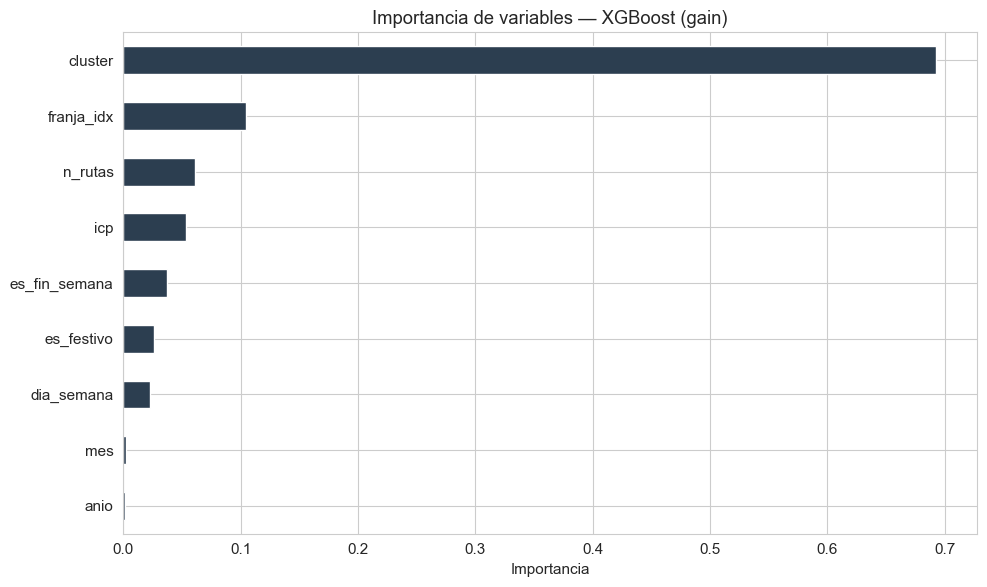

In [10]:
# =============================================
# IMPORTANCIA DE VARIABLES
# =============================================

importance = pd.Series(xgb_full.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind='barh', ax=ax, color='#2c3e50')
ax.set_title('Importancia de variables — XGBoost (gain)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig5_importancia_variables.png'), dpi=150, bbox_inches='tight')
plt.show()

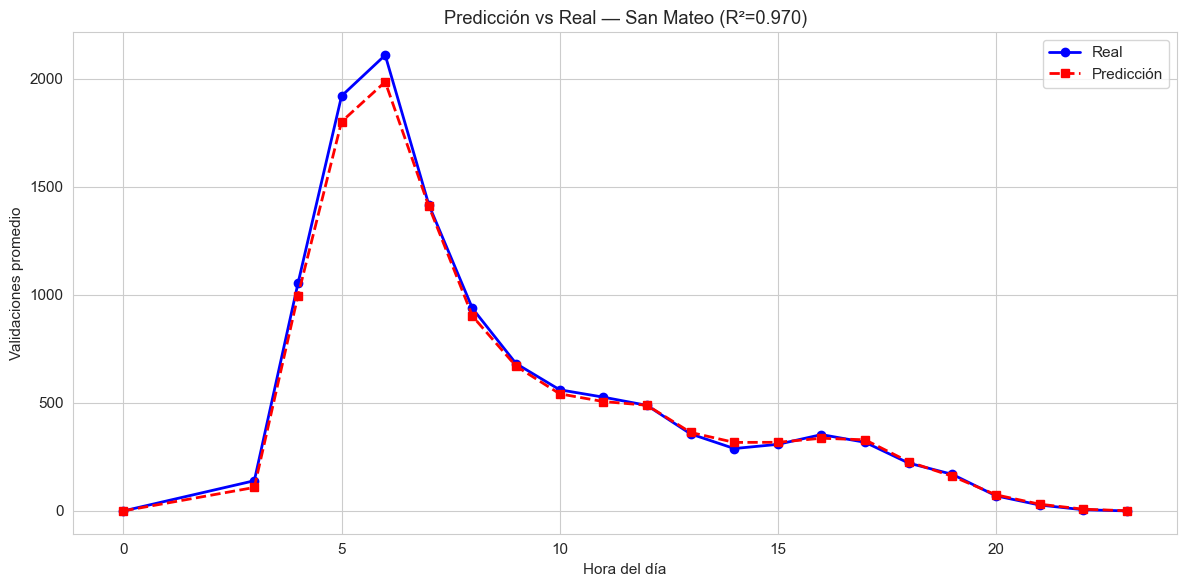

In [11]:
# =============================================
# PREDICCIÓN VS REAL — ESTACIÓN EJEMPLO
# =============================================

test_df = model_df[~train_mask].copy()
test_df['y_pred'] = y_pred_full

station_r2 = {}
for est in test_df['estacion'].unique():
    mask = test_df['estacion'] == est
    if mask.sum() > 100:
        station_r2[est] = r2_score(test_df.loc[mask, 'validaciones'], test_df.loc[mask, 'y_pred'])

best_station = max(station_r2, key=station_r2.get)

est_data = test_df[test_df['estacion'] == best_station]
real_profile = est_data.groupby('hora')['validaciones'].mean()
pred_profile = est_data.groupby('hora')['y_pred'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(real_profile.index, real_profile.values, 'b-o', label='Real', linewidth=2)
ax.plot(pred_profile.index, pred_profile.values, 'r--s', label='Predicción', linewidth=2)
ax.set_title(f'Predicción vs Real — {best_station} (R²={station_r2[best_station]:.3f})')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Validaciones promedio')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig6_prediccion_vs_real.png'), dpi=150, bbox_inches='tight')
plt.show()

### Validación y diagnóstico del modelo

Validación cruzada temporal, análisis de residuos (§3.8: distribución y comportamiento por franja y estación), RMSE desagregado por estación, interpretabilidad (gain + SHAP, complementados con *permutation importance*) e intervalos de confianza por bootstrap. La búsqueda de hiperparámetros ya usó su propia validación cruzada temporal (TimeSeriesSplit, celda de búsqueda); la de esta sección es un **diagnóstico adicional** de la estabilidad del desempeño a lo largo del periodo.

In [12]:
# =============================================
# VALIDACIÓN CRUZADA TEMPORAL (diagnóstico)
# =============================================
# Ventana expansible manual: en cada fold se entrena con TODO lo anterior y se valida
# con el fold (equivalente a TimeSeriesSplit). No sustituye la CV de la búsqueda de
# hiperparámetros (celda de búsqueda): aquí se diagnostica la estabilidad del
# desempeño del modelo ya configurado a lo largo del periodo.

# Dividir en 5 ventanas temporales
model_df_sorted = model_df.sort_values('fecha')
total = len(model_df_sorted)
n_folds = 5
fold_size = total // n_folds

cv_results = []
print("=== VALIDACIÓN CRUZADA TEMPORAL (5 folds) ===\n")

for fold in range(n_folds):
    # Train: todo lo anterior al fold. Test: el fold.
    test_start = fold * fold_size
    test_end = (fold + 1) * fold_size if fold < n_folds - 1 else total
    
    if fold == 0:
        continue  # Skip: no hay datos de entrenamiento antes del primer fold
    
    train_idx = range(0, test_start)
    test_idx = range(test_start, test_end)
    
    X_tr = model_df_sorted.iloc[list(train_idx)][feature_cols]
    y_tr = model_df_sorted.iloc[list(train_idx)]['validaciones']
    X_te = model_df_sorted.iloc[list(test_idx)][feature_cols]
    y_te = model_df_sorted.iloc[list(test_idx)]['validaciones']
    
    xgb_cv = XGBRegressor(**xgb_params)
    xgb_cv.fit(X_tr, y_tr)
    y_pred_cv = xgb_cv.predict(X_te)
    
    rmse_cv = np.sqrt(mean_squared_error(y_te, y_pred_cv))
    r2_cv = r2_score(y_te, y_pred_cv)
    mae_cv = mean_absolute_error(y_te, y_pred_cv)
    
    fecha_start = model_df_sorted.iloc[test_start]['fecha']
    fecha_end = model_df_sorted.iloc[min(test_end-1, total-1)]['fecha']
    
    cv_results.append({
        'fold': fold, 'train_size': len(train_idx), 'test_size': len(test_idx),
        'fecha_test': f"{fecha_start.strftime('%Y-%m')} a {fecha_end.strftime('%Y-%m')}",
        'rmse': rmse_cv, 'mae': mae_cv, 'r2': r2_cv
    })
    print(f"Fold {fold}: train={len(train_idx):,}, test={len(test_idx):,}, "
          f"periodo={fecha_start.strftime('%Y-%m')}–{fecha_end.strftime('%Y-%m')}, "
          f"RMSE={rmse_cv:.2f}, R²={r2_cv:.4f}")

cv_df = pd.DataFrame(cv_results)
print(f"\nPromedio: RMSE={cv_df['rmse'].mean():.2f} ± {cv_df['rmse'].std():.2f}, "
      f"R²={cv_df['r2'].mean():.4f} ± {cv_df['r2'].std():.4f}")

=== VALIDACIÓN CRUZADA TEMPORAL (5 folds) ===

Fold 1: train=1,638,487, test=1,638,487, periodo=2024-05–2024-10, RMSE=67.52, R²=0.9301
Fold 2: train=3,276,974, test=1,638,487, periodo=2024-10–2025-03, RMSE=67.74, R²=0.9274
Fold 3: train=4,915,461, test=1,638,487, periodo=2025-03–2025-08, RMSE=58.35, R²=0.9465
Fold 4: train=6,553,948, test=1,638,490, periodo=2025-08–2025-12, RMSE=65.97, R²=0.9353

Promedio: RMSE=64.90 ± 4.43, R²=0.9348 ± 0.0085


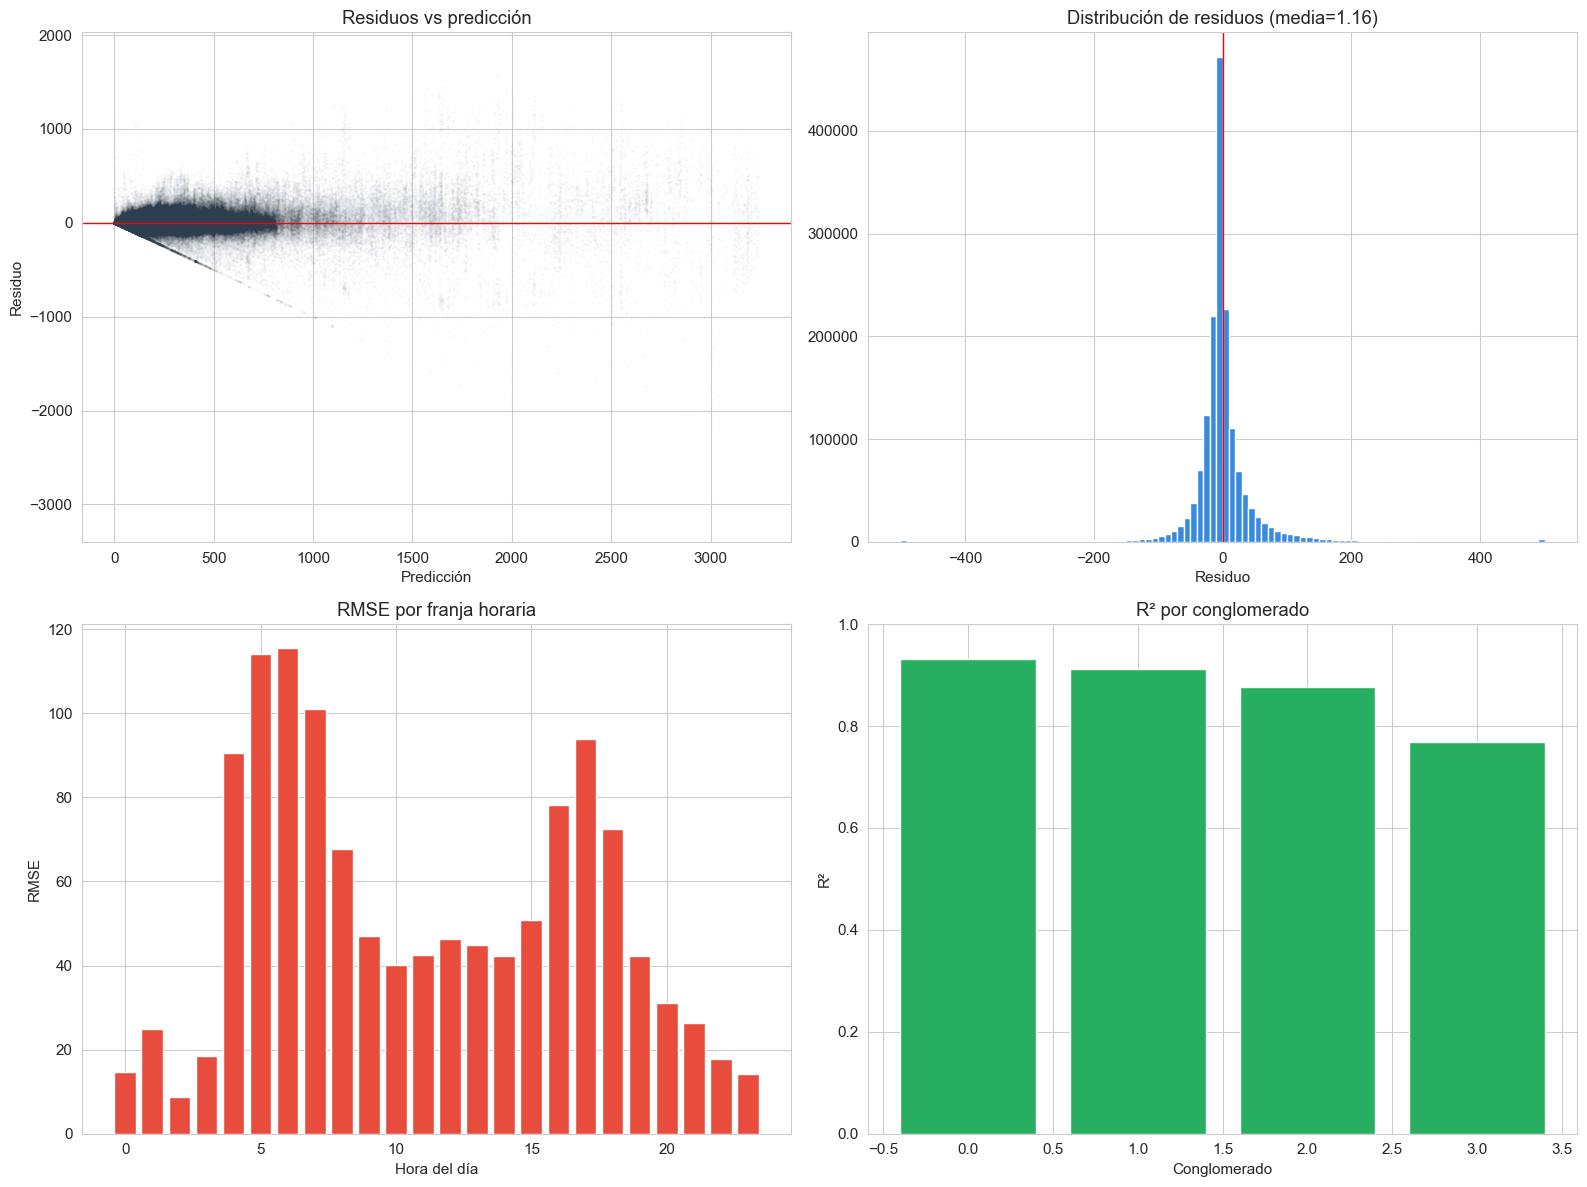

In [13]:
# =============================================
# ANÁLISIS DE RESIDUOS
# =============================================

test_df = model_df[~train_mask].copy()
test_df['y_pred'] = y_pred_full
test_df['residuo'] = test_df['validaciones'] - test_df['y_pred']
test_df['residuo_pct'] = test_df['residuo'] / (test_df['validaciones'] + 1) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Residuos vs predicción
axes[0,0].scatter(test_df['y_pred'], test_df['residuo'], alpha=0.01, s=1, c='#2c3e50')
axes[0,0].axhline(y=0, color='red', linewidth=1)
axes[0,0].set_xlabel('Predicción')
axes[0,0].set_ylabel('Residuo')
axes[0,0].set_title('Residuos vs predicción')

# Panel 2: Distribución de residuos
axes[0,1].hist(test_df['residuo'].clip(-500, 500), bins=100, color='#378ADD', edgecolor='white')
axes[0,1].axvline(x=0, color='red', linewidth=1)
axes[0,1].set_xlabel('Residuo')
axes[0,1].set_title(f'Distribución de residuos (media={test_df["residuo"].mean():.2f})')

# Panel 3: RMSE por hora
rmse_hora = test_df.groupby('hora').apply(
    lambda g: np.sqrt(mean_squared_error(g['validaciones'], g['y_pred']))
).reset_index(name='rmse')
axes[1,0].bar(rmse_hora['hora'], rmse_hora['rmse'], color='#e74c3c')
axes[1,0].set_xlabel('Hora del día')
axes[1,0].set_ylabel('RMSE')
axes[1,0].set_title('RMSE por franja horaria')

# Panel 4: R² por conglomerado
r2_cluster = test_df.groupby('cluster').apply(
    lambda g: r2_score(g['validaciones'], g['y_pred']) if len(g) > 10 else np.nan
).reset_index(name='r2')
r2_cluster['cluster'] = r2_cluster['cluster'].astype(int)
axes[1,1].bar(r2_cluster['cluster'], r2_cluster['r2'], color='#27ae60')
axes[1,1].set_xlabel('Conglomerado')
axes[1,1].set_ylabel('R²')
axes[1,1].set_title('R² por conglomerado')
axes[1,1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_analisis_residuos.png'), dpi=150, bbox_inches='tight')
plt.show()

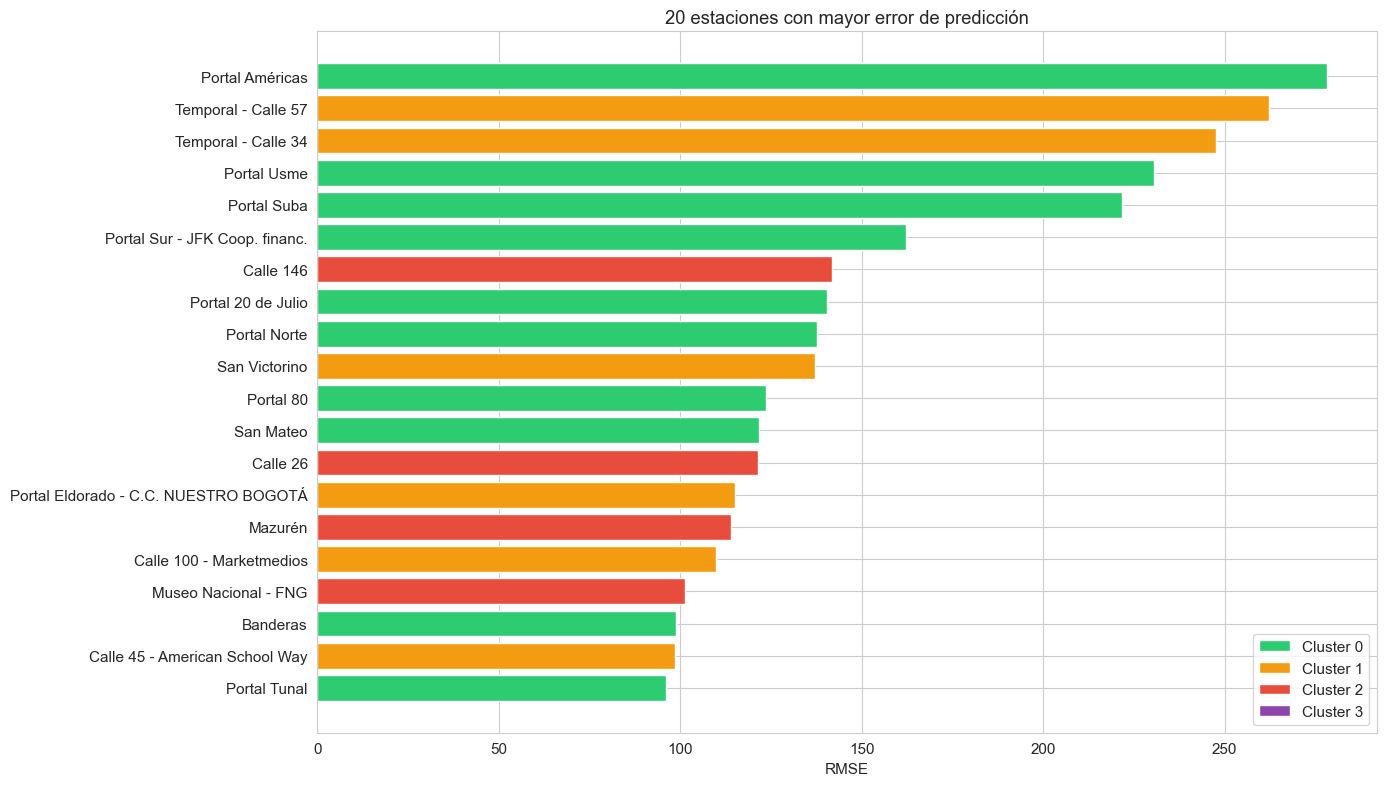

Estaciones con R² < 0.80: 54 de 139
Estaciones con R² > 0.95: 6
R² por estación — mediana: 0.839 | P25: 0.746 | mín: -460229.688


In [14]:
# =============================================
# RMSE DESAGREGADO POR ESTACIÓN
# =============================================

rmse_est = test_df.groupby('estacion').apply(
    lambda g: pd.Series({
        'rmse': np.sqrt(mean_squared_error(g['validaciones'], g['y_pred'])),
        'r2': r2_score(g['validaciones'], g['y_pred']) if len(g) > 10 else np.nan,
        'n': len(g),
        'cluster': int(g['cluster'].mode().iloc[0]) if len(g) > 0 else -1
    })
).reset_index()

fig, ax = plt.subplots(figsize=(14, 8))
worst_20 = rmse_est.nlargest(20, 'rmse')
colors_map = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c', 3: '#8e44ad'}
bar_colors = [colors_map.get(int(c), '#999') for c in worst_20['cluster']]
ax.barh(range(len(worst_20)), worst_20['rmse'].values, color=bar_colors)
ax.set_yticks(range(len(worst_20)))
ax.set_yticklabels(worst_20['estacion'].values)
ax.set_xlabel('RMSE')
ax.set_title('20 estaciones con mayor error de predicción')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'Cluster {k}') for k, c in colors_map.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_rmse_por_estacion.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Estaciones con R² < 0.80: {(rmse_est['r2'] < 0.80).sum()} de {rmse_est['r2'].notna().sum()}")
print(f"Estaciones con R² > 0.95: {(rmse_est['r2'] > 0.95).sum()}")
print(f"R² por estación — mediana: {rmse_est['r2'].median():.3f} | "
      f"P25: {rmse_est['r2'].quantile(0.25):.3f} | mín: {rmse_est['r2'].min():.3f}")


**Lectura.** El R² agregado está dominado por las estaciones de alto volumen; la dispersión por estación (mediana y P25 anteriores) muestra que el ajuste no es uniforme. Conviene reportar la mediana por estación junto al R² agregado y revisar las estaciones de menor ajuste, varias de ellas afectadas por cierres o con demanda casi nula, donde el R² deja de ser informativo.

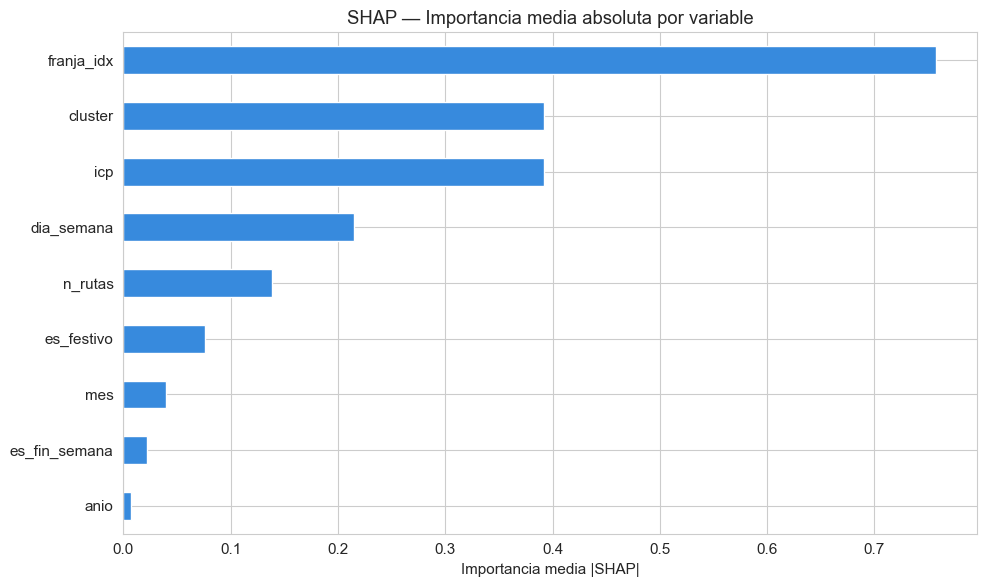

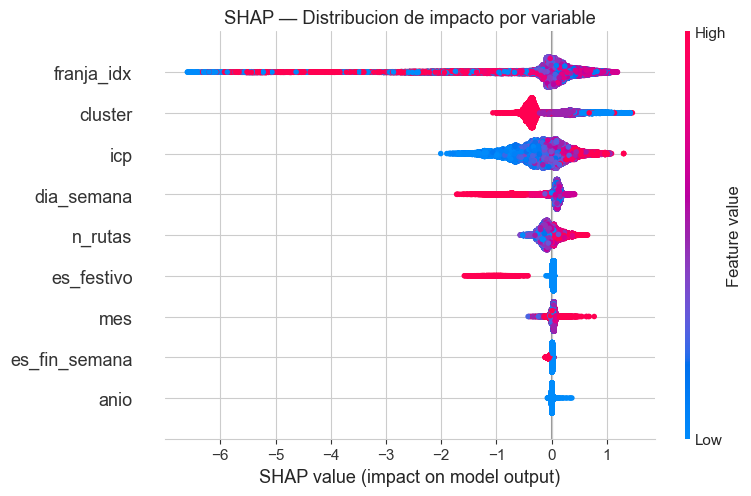

=== COMPARACION: GAIN vs SHAP (normalizado) ===
                gain   shap
franja_idx     0.104  0.371
cluster        0.693  0.192
icp            0.053  0.192
dia_semana     0.022  0.105
n_rutas        0.061  0.068
es_festivo     0.026  0.037
mes            0.002  0.019
es_fin_semana  0.037  0.011
anio           0.001  0.003


In [15]:
# =============================================
# SHAP VALUES
# =============================================
# Se calculan los valores SHAP con la funcion nativa de XGBoost (pred_contribs),
# que es TreeSHAP, para evitar la incompatibilidad de versiones entre shap y
# xgboost al cargar el modelo. shap se usa solo para la visualizacion.
import xgboost as xgb

# Muestra para velocidad
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(50000, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]

# SHAP nativo de XGBoost: la ultima columna es el sesgo (base value), se descarta
dmatrix = xgb.DMatrix(X_sample)
shap_contribs = xgb_full.get_booster().predict(dmatrix, pred_contribs=True)
shap_values = shap_contribs[:, :-1]

# Importancia media |SHAP| por variable
shap_mean = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)

# Grafico 1: barra de importancia media |SHAP| (controlado, sin summary_plot)
fig, ax = plt.subplots(figsize=(10, 6))
shap_mean.sort_values().plot(kind='barh', ax=ax, color='#378ADD')
ax.set_xlabel('Importancia media |SHAP|')
ax.set_title('SHAP — Importancia media absoluta por variable')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_shap_importancia.png'), dpi=150, bbox_inches='tight')
plt.show()

# Grafico 2: beeswarm (distribucion de impacto). Figura propia de shap.
try:
    shap.summary_plot(shap_values, X_sample, max_display=10, show=False)
    plt.title('SHAP — Distribucion de impacto por variable')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FIG, 'fig_shap_beeswarm.png'), dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"(No se pudo generar el beeswarm: {e})")

# Comparacion gain vs SHAP (normalizado)
gain_importance = pd.Series(xgb_full.feature_importances_, index=feature_cols)
comp_imp = pd.DataFrame({
    'gain': gain_importance / gain_importance.sum(),
    'shap': shap_mean / shap_mean.sum()
}).sort_values('shap', ascending=False)

print("=== COMPARACION: GAIN vs SHAP (normalizado) ===")
print(comp_imp.round(3).to_string())

=== PERMUTATION IMPORTANCE ===
     variable  importance_mean  importance_std
   franja_idx     74617.737988      943.871853
      cluster     39641.217676      339.911403
          icp     38609.917676      338.846252
   dia_semana     15428.217676      352.979876
      n_rutas      6494.558691       95.238767
   es_festivo      4642.836035      222.727376
          mes       373.590186       34.348559
es_fin_semana       301.211328       16.919118
         anio         0.000000        0.000000


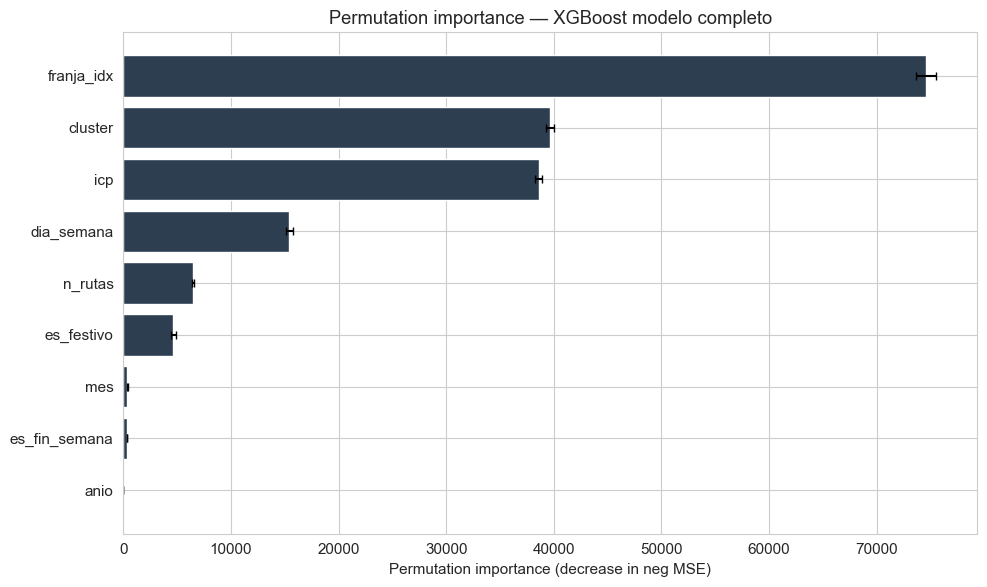

In [16]:
# =============================================
# PERMUTATION IMPORTANCE
# =============================================

from sklearn.inspection import permutation_importance

# Usar muestra para velocidad
sample_size = min(100000, len(X_test))
sample_idx = np.random.RandomState(42).choice(len(X_test), size=sample_size, replace=False)

perm_result = permutation_importance(
    xgb_full, X_test.iloc[sample_idx], y_test.iloc[sample_idx],
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring='neg_mean_squared_error'
)

perm_df = pd.DataFrame({
    'variable': feature_cols,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print("=== PERMUTATION IMPORTANCE ===")
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
perm_df_sorted = perm_df.sort_values('importance_mean')
ax.barh(perm_df_sorted['variable'], perm_df_sorted['importance_mean'],
        xerr=perm_df_sorted['importance_std'], color='#2c3e50', capsize=3)
ax.set_xlabel('Permutation importance (decrease in neg MSE)')
ax.set_title('Permutation importance — XGBoost modelo completo')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_permutation_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

Block bootstrap por estación: 1000 iteraciones sobre 139 estaciones...

=== IC 95% (BLOCK BOOTSTRAP POR ESTACIÓN) ===
  RMSE (M2): 52.86 — 79.59 (punto: 65.86)
  R²   (M2): 0.9189 — 0.9472 (punto: 0.9356)

=== DIFERENCIA M2 (ESTRUCTURAL) vs M0 (TEMPORAL) ===
  ΔRMSE: 132.22 — 217.05 (punto: 175.28)
  ΔR²:   0.7646 — 0.8257 (punto: 0.7993)

  En 100.0% de los remuestreos por estación, M2 supera a M0.


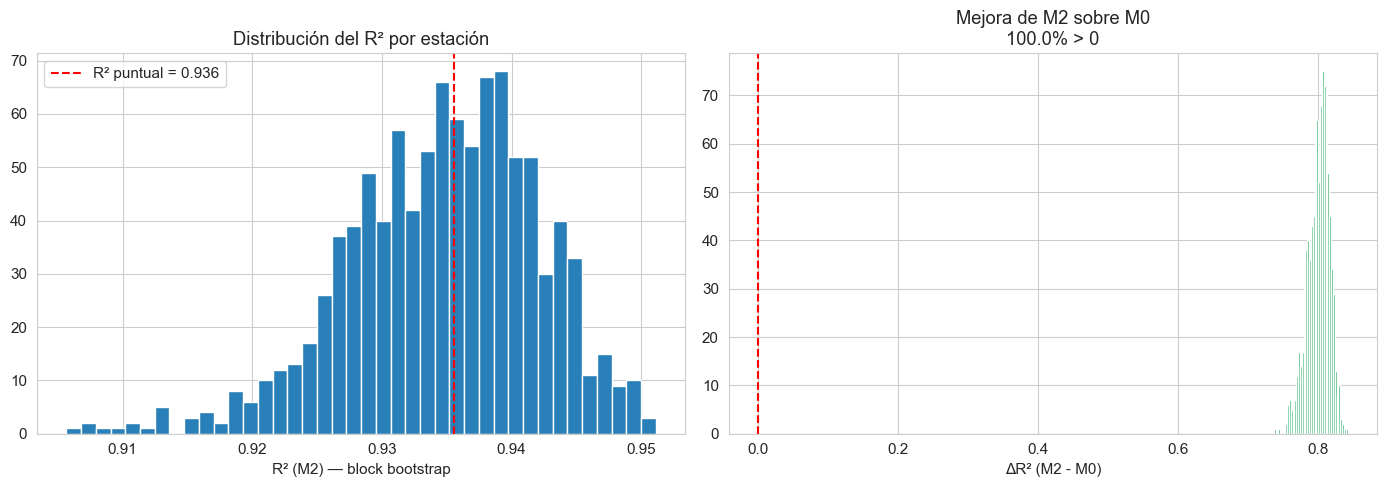

In [17]:
# =============================================
# BLOCK BOOTSTRAP POR ESTACIÓN: IC para las métricas
# =============================================
# El bootstrap iid sobre filas subestima la incertidumbre: las filas de una misma
# estación están correlacionadas. Se remuestrean ESTACIONES con reemplazo (bloques),
# conservando todas las filas de cada una. Da intervalos honestos (más anchos).

n_bootstrap = 1000

tb = model_df.loc[~train_mask, ['estacion', 'validaciones']].reset_index(drop=True)
tb['yp_full'] = y_pred_full
tb['yp_base'] = y_pred_base
_val = tb['validaciones'].to_numpy(); _pf = tb['yp_full'].to_numpy(); _pb = tb['yp_base'].to_numpy()
_est = tb['estacion'].to_numpy()
estaciones_test = np.unique(_est)
idx_por_est = {e: np.where(_est == e)[0] for e in estaciones_test}

rng = np.random.default_rng(42)
boot_rmse, boot_r2, boot_rmse_base, boot_r2_base = [], [], [], []
print(f"Block bootstrap por estación: {n_bootstrap} iteraciones sobre {len(estaciones_test)} estaciones...\n")
for _ in range(n_bootstrap):
    muestra = rng.choice(estaciones_test, size=len(estaciones_test), replace=True)
    idx = np.concatenate([idx_por_est[e] for e in muestra])
    boot_rmse.append(np.sqrt(mean_squared_error(_val[idx], _pf[idx])))
    boot_r2.append(r2_score(_val[idx], _pf[idx]))
    boot_rmse_base.append(np.sqrt(mean_squared_error(_val[idx], _pb[idx])))
    boot_r2_base.append(r2_score(_val[idx], _pb[idx]))

boot_rmse = np.array(boot_rmse); boot_r2 = np.array(boot_r2)
boot_rmse_base = np.array(boot_rmse_base); boot_r2_base = np.array(boot_r2_base)

print("=== IC 95% (BLOCK BOOTSTRAP POR ESTACIÓN) ===")
print(f"  RMSE (M2): {np.percentile(boot_rmse, 2.5):.2f} — {np.percentile(boot_rmse, 97.5):.2f} (punto: {rmse_full:.2f})")
print(f"  R²   (M2): {np.percentile(boot_r2, 2.5):.4f} — {np.percentile(boot_r2, 97.5):.4f} (punto: {r2_full:.4f})")

delta_rmse = boot_rmse_base - boot_rmse
delta_r2   = boot_r2 - boot_r2_base
print("\n=== DIFERENCIA M2 (ESTRUCTURAL) vs M0 (TEMPORAL) ===")
print(f"  ΔRMSE: {np.percentile(delta_rmse, 2.5):.2f} — {np.percentile(delta_rmse, 97.5):.2f} (punto: {rmse_base-rmse_full:.2f})")
print(f"  ΔR²:   {np.percentile(delta_r2, 2.5):.4f} — {np.percentile(delta_r2, 97.5):.4f} (punto: {r2_full-r2_base:.4f})")
pct = (delta_rmse > 0).mean() * 100
print(f"\n  En {pct:.1f}% de los remuestreos por estación, M2 supera a M0.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(boot_r2, bins=40, color='#2980b9', edgecolor='white')
axes[0].axvline(r2_full, color='red', linestyle='--', label=f'R² puntual = {r2_full:.3f}')
axes[0].set_xlabel('R² (M2) — block bootstrap'); axes[0].set_title('Distribución del R² por estación'); axes[0].legend()
axes[1].hist(delta_r2, bins=40, color='#27ae60', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('ΔR² (M2 - M0)'); axes[1].set_title(f'Mejora de M2 sobre M0\n{pct:.1f}% > 0')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_bootstrap_metricas.png'), dpi=150, bbox_inches='tight')
plt.show()

**Lectura.** El intervalo del bootstrap por estación es ancho: refleja la incertidumbre real de un panel donde los errores se correlacionan dentro de cada estación, a diferencia del bootstrap sobre filas independientes, que la subestima. Aun así, la diferencia M2 frente a M0 se mantiene positiva en prácticamente todos los remuestreos, de modo que la ventaja del modelo estructural sobre el puramente temporal es robusta a esa incertidumbre.

### Anticipación de franjas de presión (cierra el OE5)

Umbrales sobre el IPD esperado (§3.8): **1,0** marca presión **alta** —la demanda proyectada alcanza la cobertura ponderada de referencia (el numerador iguala al denominador)— y **1,5** presión **severa** —la supera en un 50%—. Son cortes de lectura sobre una medida relativa, no niveles físicos de saturación; por eso abajo se reporta también la sensibilidad del desempeño a umbrales alternativos (0,8 / 1,0 / 1,2).

In [18]:
# =============================================================
# ANTICIPACIÓN DE FRANJAS DE PRESIÓN ALTA
# -------------------------------------------------------------
# IPD esperado = demanda predicha (M2) / ICP de la estacion.
#   - Presion alta:    IPD esperado >= 1.0
#   - Presion severa: IPD esperado >= 1.5
# ATENCION: estos umbrales NO representan saturacion fisica. El ICP es
# estatico e ignora la frecuencia, y su magnitud varia entre estaciones,
# por lo que un mismo IPD equivale a cargas absolutas distintas (ver §3.8).
# Se interpretan como PRESION RELATIVA a la cobertura asignada. Abajo se
# reporta la sensibilidad del desempeno a la eleccion del umbral.
# =============================================================
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

UMBRAL_ALTA = 1.0
UMBRAL_SEV = 1.5

# test_df (definido en celdas previas) tiene 'validaciones', 'y_pred', 'icp', 'estacion', 'hora'
pres = test_df[test_df['icp'] > 0].copy()
pres['ipd_real']     = pres['validaciones'] / pres['icp']
pres['ipd_esperado'] = pres['y_pred']       / pres['icp']

pres['alta_real'] = (pres['ipd_real']     >= UMBRAL_ALTA).astype(int)
pres['alta_pred'] = (pres['ipd_esperado'] >= UMBRAL_ALTA).astype(int)
pres['sev_real'] = (pres['ipd_real']     >= UMBRAL_SEV).astype(int)
pres['sev_pred'] = (pres['ipd_esperado'] >= UMBRAL_SEV).astype(int)


def evaluar(y_true, y_pred, etiqueta):
    cm = confusion_matrix(y_true, y_pred)
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"--- {etiqueta} ---")
    print(f"  Franjas observadas:   {int(y_true.sum()):,}")
    print(f"  Franjas anticipadas:  {int(y_pred.sum()):,}")
    print(f"  Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")
    print(f"  Matriz de confusion [[TN FP] [FN TP]]:\n{cm}\n")
    return p, r, f1


print("=" * 60)
print("ANTICIPACION DE FRANJAS DE PRESION — CONJUNTO DE PRUEBA")
print(f"Registros evaluados: {len(pres):,}")
print("=" * 60 + "\n")
evaluar(pres['alta_real'], pres['alta_pred'], f"Presion alta (IPD esperado >= {UMBRAL_ALTA})")
evaluar(pres['sev_real'], pres['sev_pred'], f"Presion severa (IPD esperado >= {UMBRAL_SEV})")

# --- Sensibilidad a la eleccion del umbral (robustez, §3.8) ---
print("Sensibilidad del desempeno al umbral de presion:")
print(f"  {'Umbral':>7}{'Precision':>11}{'Recall':>9}{'F1':>7}")
for u in [0.8, 1.0, 1.2]:
    yt = (pres['ipd_real'] >= u).astype(int)
    yp = (pres['ipd_esperado'] >= u).astype(int)
    print(f"  {u:>7.1f}{precision_score(yt, yp, zero_division=0):>11.3f}"
          f"{recall_score(yt, yp, zero_division=0):>9.3f}{f1_score(yt, yp, zero_division=0):>7.3f}")

# Estaciones donde mas se anticipa presion alta
resumen_estacion = (
    pres.groupby('estacion')
        .agg(intervalos=('alta_pred', 'size'),
             franjas_anticipadas=('alta_pred', 'sum'),
             franjas_observadas=('alta_real', 'sum'),
             ipd_esperado_max=('ipd_esperado', 'max'))
        .assign(tasa_anticipada=lambda d: d['franjas_anticipadas'] / d['intervalos'])
        .sort_values('franjas_anticipadas', ascending=False)
        .head(15)
)
print("\nTop 15 estaciones por franjas de presion alta anticipadas:")
print(resumen_estacion.round(3).to_string())

# Franjas horarias con mayor proporcion de presion alta anticipada
resumen_hora = pres.groupby('hora')['alta_pred'].mean().sort_values(ascending=False).head(8)
print("\nFranjas horarias con mayor proporcion de presion alta anticipada (%):")
print((resumen_hora * 100).round(1).to_string())

ANTICIPACION DE FRANJAS DE PRESION — CONJUNTO DE PRUEBA
Registros evaluados: 1,633,442

--- Presion alta (IPD esperado >= 1.0) ---
  Franjas observadas:   4,912
  Franjas anticipadas:  1,351
  Precision: 0.839 | Recall: 0.231 | F1: 0.362
  Matriz de confusion [[TN FP] [FN TP]]:
[[1628312     218]
 [   3779    1133]]

--- Presion severa (IPD esperado >= 1.5) ---
  Franjas observadas:   100
  Franjas anticipadas:  0
  Precision: 0.000 | Recall: 0.000 | F1: 0.000
  Matriz de confusion [[TN FP] [FN TP]]:
[[1633342       0]
 [    100       0]]

Sensibilidad del desempeno al umbral de presion:
   Umbral  Precision   Recall     F1
      0.8      0.826    0.536  0.651
      1.0      0.839    0.231  0.362
      1.2      0.917    0.198  0.325

Top 15 estaciones por franjas de presion alta anticipadas:
                          intervalos  franjas_anticipadas  franjas_observadas  ipd_esperado_max  tasa_anticipada
estacion                                                                            

## 2. Exportación de resultados

Se exportan el panel completo con IPD (`ipd_completo.csv`, no versionado por tamaño) y las métricas de los modelos. El ICP por estación y la tabla de conglomerados ya quedan exportados por los cuadernos 02 y 03 (`icp_por_estacion.csv`, `conglomerados_por_estacion.csv`) y no se duplican aquí.

In [19]:
# =============================================
# GUARDAR RESULTADOS
# =============================================

# icp y cluster_df ya quedan exportados por 02 (icp_por_estacion.csv) y
# 03 (conglomerados_por_estacion.csv); no se duplican aquí.

ipd_export = ipd_df[['estacion', 'fecha', 'intervalo', 'hora', 'dia_semana', 'mes',
                     'validaciones', 'icp', 'n_rutas', 'ipd', 'cluster']].copy()
ipd_export.to_csv(os.path.join(OUT_TAB, 'ipd_completo.csv'), index=False)
print(f"Guardado: ipd_completo.csv ({len(ipd_export):,} filas)")

metricas = pd.DataFrame({
    'Modelo': ['M0 (temporal)', 'M1 (efectos fijos, entero)', 'M2 (estructural)',
               'M3 (M2 + rezago 7d, filas con rezago)', 'Random Forest (M2)'],
    'RMSE': [rmse_base, rmse_m1, rmse_full, rmse_m3, rmse_rf],
    'MAE':  [mae_base,  mae_m1,  mae_full,  mae_m3,  mae_rf],
    'R2':   [r2_base,   r2_m1,   r2_full,   r2_m3,   r2_rf]
})
print("NOTA: M3 se evalúa solo sobre las filas que tienen rezago; comparar M3 contra el")
print("      M2 reevaluado en esas mismas filas (ver celda del modelo M3), no contra el R2 de arriba.")
metricas.to_csv(os.path.join(OUT_TAB, 'metricas_modelo.csv'), index=False)
print("Guardado: metricas_modelo.csv")
print(metricas.round(4).to_string(index=False))
print("\nTodos los resultados exportados.")

Guardado: ipd_completo.csv (8,192,438 filas)
NOTA: M3 se evalúa solo sobre las filas que tienen rezago; comparar M3 contra el
      M2 reevaluado en esas mismas filas (ver celda del modelo M3), no contra el R2 de arriba.
Guardado: metricas_modelo.csv
                               Modelo     RMSE      MAE     R2
                        M0 (temporal) 241.1414 115.0888 0.1363
           M1 (efectos fijos, entero)  70.2262  34.7061 0.9267
                     M2 (estructural)  65.8569  28.7407 0.9356
M3 (M2 + rezago 7d, filas con rezago)  55.5851  22.3005 0.9542
                   Random Forest (M2) 109.7033  55.5809 0.8212

Todos los resultados exportados.
